# 02 — HYPOTHESIS TESTING — `ChurnGuard`
# Objectif : Valider statistiquement les hypothèses de l'EDA
# Auteur   : `Romaric TCHOFFO`




In [ ]:
# NETTOYAGE MINIMAL
# On nettoie uniquement les colonnes testées
# Le nettoyage complet est dans 03_preprocessing.ipynb


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
df = pd.read_csv("../data/raw/churn_dataset_messy.csv")
df_test = df.copy()  # Copie indépendante pour ne jamais modifier df original


In [8]:

df_test["Age"]               = pd.to_numeric(df_test["Age"],errors="coerce")
df_test["Balance"]           = pd.to_numeric(df_test["Balance"],errors="coerce")
df_test["CreditScore"]       = pd.to_numeric(df_test["CreditScore"], errors="coerce")
df_test["EstimatedSalary"]   = pd.to_numeric(df_test["EstimatedSalary"], errors="coerce")
df_test["SatisfactionScore"] = pd.to_numeric(df_test["SatisfactionScore"],errors="coerce")

# Garder uniquement les valeurs valides de SatisfactionScore [1-5]
df_test["SatisfactionScore"] = df_test["SatisfactionScore"].where(
                                df_test["SatisfactionScore"].between(1, 5))

# Mapping IsActiveMember vers 0/1 — valeurs incohérentes détectées en EDA
mapping_active = {1:1, 0:0, "1":1, "0":0,
                  "active":1, "inactive":0, "Y":1, "N":0}
df_test["IsActiveMember"] = df_test["IsActiveMember"].map(mapping_active)


In [9]:
# Mapping Geography — valeurs incohérentes détectées en EDA
mapping_geo = {
    "Germany":"Germany", "GERMANY":"Germany", "Allemagne":"Germany",
    "France":"France",   "france":"France",   "Frnace":"France",
    "Spain":"Spain",     "Espagne":"Spain"
}
df_test["Geography"] = df_test["Geography"].map(mapping_geo)

# Suppression des NaN uniquement sur les colonnes testées
df_test = df_test.dropna(subset=["Age", "Balance", "CreditScore",
                                  "EstimatedSalary", "IsActiveMember",
                                  "SatisfactionScore", "Geography", "Exited"])

print(f"Shape original : {df.shape}")
print(f"Shape df_test  : {df_test.shape}")

Shape original : (15750, 18)
Shape df_test  : (11660, 18)


In [13]:
# ÉTAPE 1 — TEST DE NORMALITÉ (SHAPIRO-WILK)
# Objectif : Déterminer quel test utiliser pour chaque variable
# Règle    : p > 0.05 → Normale → T-test
#            p < 0.05 → Non normale → Mann-Whitney
# Note     : On échantillonne à 5000 car Shapiro est lent
#            sur de grands datasets. random_state=42 pour
#            la reproductibilité des résultats.

print("TEST DE NORMALITÉ — SHAPIRO-WILK")
print("-"*50)

cols_continues = ["Age", "Balance", "CreditScore", "EstimatedSalary"]

resultats_shapiro = {}  # On stocke les résultats pour décider le test ensuite

for col in cols_continues:
    stat, p = stats.shapiro(df_test[col].sample(5000, random_state=42))
    normalite = "Normale" if p > 0.05 else "Non normale"
    resultats_shapiro[col] = normalite
    print(f"{col:20} → p-value = {p:.6f}  : {normalite}")

print("\nConclusion : Toutes les variables sont non normales")
print("On utilise Mann-Whitney pour toutes les continues")

TEST DE NORMALITÉ — SHAPIRO-WILK
--------------------------------------------------
Age                  → p-value = 0.000000  : Non normale
Balance              → p-value = 0.000000  : Non normale
CreditScore          → p-value = 0.000000  : Non normale
EstimatedSalary      → p-value = 0.000000  : Non normale

Conclusion : Toutes les variables sont non normales
On utilise Mann-Whitney pour toutes les continues


In [17]:
# ÉTAPE 2 — MANN-WHITNEY : AGE vs EXITED
# Objectif : Vérifier si l'âge influence le churn
# H0 : La distribution d'Age est identique
#      entre churners et non-churners
# H1 : La distribution d'Age est différente
#      entre churners et non-churners
# Test choisi : Mann-Whitney car Age est non normale (Shapiro)


churners     = df_test[df_test["Exited"] == 1]["Age"]
non_churners = df_test[df_test["Exited"] == 0]["Age"]

stat, p = stats.mannwhitneyu(churners, non_churners, alternative="two-sided")

print("MANN-WHITNEY — Age vs Exited")
print("-"*50)
print(f"H0              : Age identique entre churners et non-churners")
print(f"Statistique U   : {stat:.2f}")
print(f"p-value         : {p:.6f}")
print(f"Seuil alpha     : 0.05")
print(f"Conclusion      : {'H0 rejetée → Age influence significativement le churn' if p < 0.05 else 'H0 non rejetée → Age sans effet significatif'}")
print(f"\nAge moyen — Non-churn : {non_churners.mean():.1f} ans")
print(f"Age moyen — Churn     : {churners.mean():.1f} ans")
print(f"Différence            : {churners.mean() - non_churners.mean():.1f} ans")


MANN-WHITNEY — Age vs Exited
--------------------------------------------------
H0              : Age identique entre churners et non-churners
Statistique U   : 13879694.50
p-value         : 0.000000
Seuil alpha     : 0.05
Conclusion      : H0 rejetée → Age influence significativement le churn

Age moyen — Non-churn : 40.0 ans
Age moyen — Churn     : 42.3 ans
Différence            : 2.3 ans


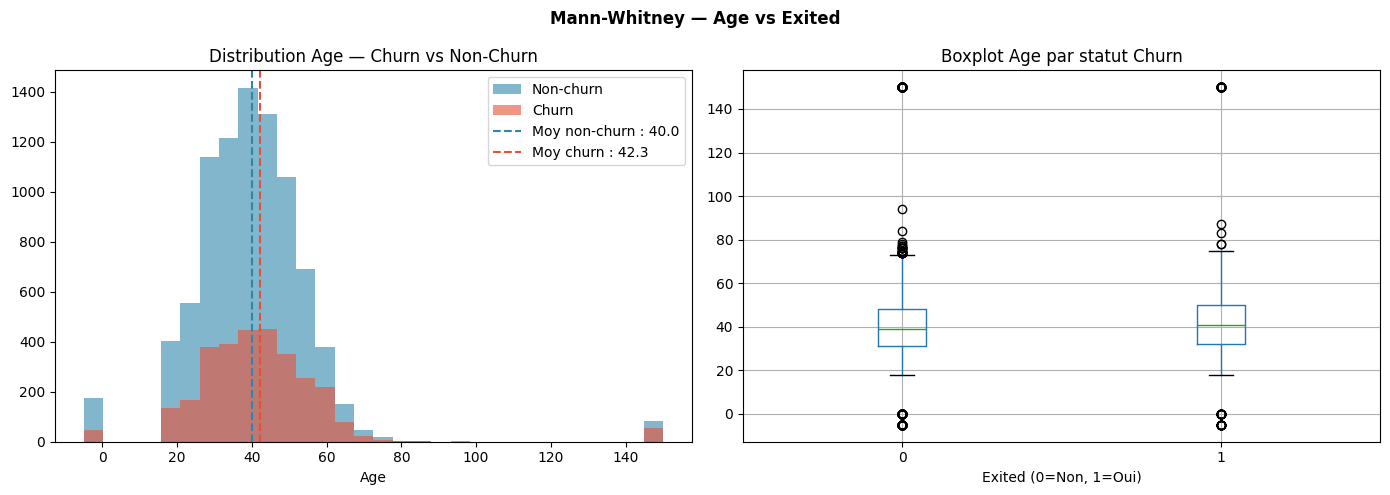

In [16]:
# Visualisation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(non_churners, bins=30, alpha=0.6, color="#2E86AB", label="Non-churn")
ax1.hist(churners,     bins=30, alpha=0.6, color="#E94F37", label="Churn")
ax1.axvline(non_churners.mean(), color="#2E86AB", linestyle="--",
            label=f"Moy non-churn : {non_churners.mean():.1f}")
ax1.axvline(churners.mean(),     color="#E94F37", linestyle="--",
            label=f"Moy churn : {churners.mean():.1f}")
ax1.set_title("Distribution Age — Churn vs Non-Churn")
ax1.set_xlabel("Age")
ax1.legend()

df_test.boxplot(column="Age", by="Exited", ax=ax2)
ax2.set_title("Boxplot Age par statut Churn")
ax2.set_xlabel("Exited (0=Non, 1=Oui)")

plt.suptitle("Mann-Whitney — Age vs Exited", fontweight="bold")
plt.tight_layout()
plt.show()

In [20]:
# ÉTAPE 3 — MANN-WHITNEY : BALANCE vs EXITED
# Objectif : Vérifier si le solde influence le churn
# H0 : La distribution de Balance est identique
#      entre churners et non-churners
# H1 : La distribution de Balance est différente
# Test choisi : Mann-Whitney car Balance est non normale
# Note : Balance contient des valeurs corrompues (jusqu'à 1Mrd)
#        détectées en EDA → résultats à confirmer après preprocessing

churners_b     = df_test[df_test["Exited"] == 1]["Balance"]
non_churners_b = df_test[df_test["Exited"] == 0]["Balance"]

stat, p = stats.mannwhitneyu(churners_b, non_churners_b, alternative="two-sided")

print("MANN-WHITNEY — Balance vs Exited")
print("-"*50)
print(f"H0              : Balance identique entre churners et non-churners")
print(f"Statistique U   : {stat:.2f}")
print(f"p-value         : {p:.6f}")
print(f"Seuil alpha     : 0.05")
print(f"Conclusion      : {'H0 rejetée → Balance influence significativement le churn' if p < 0.05 else 'H0 non rejetée → Balance sans effet significatif'}")
print(f"\nBalance moyenne — Non-churn : {non_churners_b.mean():.2f}")
print(f"Balance moyenne — Churn     : {churners_b.mean():.2f}")


MANN-WHITNEY — Balance vs Exited
--------------------------------------------------
H0              : Balance identique entre churners et non-churners
Statistique U   : 13163120.50
p-value         : 0.343920
Seuil alpha     : 0.05
Conclusion      : H0 non rejetée → Balance sans effet significatif

Balance moyenne — Non-churn : 4229859.45
Balance moyenne — Churn     : 6386150.50


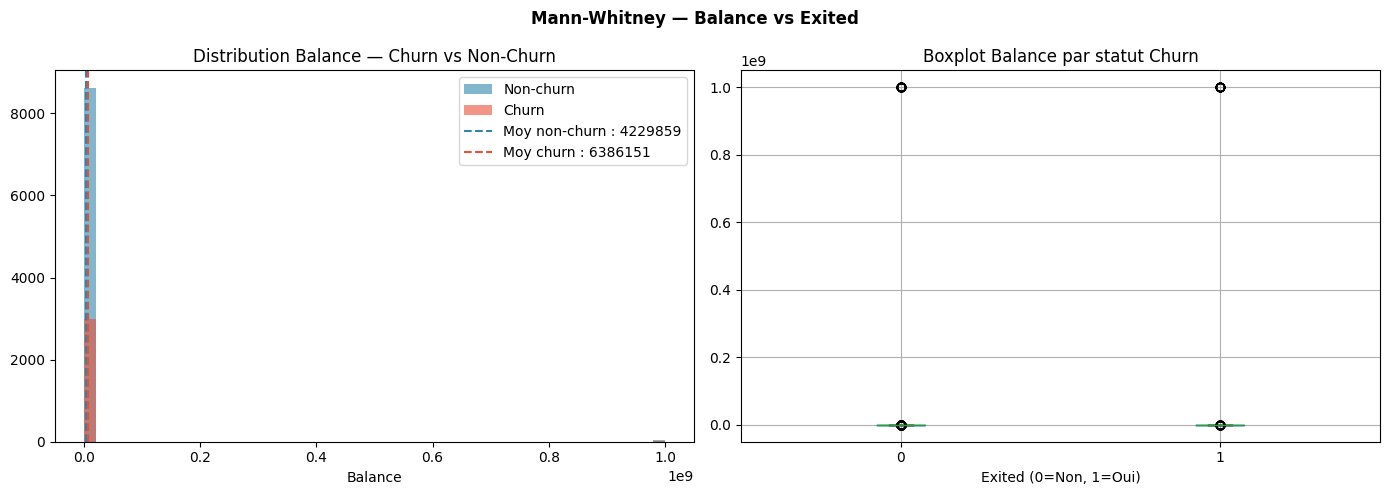

In [19]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(non_churners_b, bins=50, alpha=0.6, color="#2E86AB", label="Non-churn")
ax1.hist(churners_b,     bins=50, alpha=0.6, color="#E94F37", label="Churn")
ax1.axvline(non_churners_b.mean(), color="#2E86AB", linestyle="--",
            label=f"Moy non-churn : {non_churners_b.mean():.0f}")
ax1.axvline(churners_b.mean(),     color="#E94F37", linestyle="--",
            label=f"Moy churn : {churners_b.mean():.0f}")
ax1.set_title("Distribution Balance — Churn vs Non-Churn")
ax1.set_xlabel("Balance")
ax1.legend()

df_test.boxplot(column="Balance", by="Exited", ax=ax2)
ax2.set_title("Boxplot Balance par statut Churn")
ax2.set_xlabel("Exited (0=Non, 1=Oui)")

plt.suptitle("Mann-Whitney — Balance vs Exited", fontweight="bold")
plt.tight_layout()
plt.show()

In [21]:
# ÉTAPE 4 — MANN-WHITNEY : CREDITSCORE vs EXITED
# Objectif : Vérifier si le score de crédit influence le churn
# H0 : CreditScore identique entre churners et non-churners
# H1 : CreditScore différent entre les deux groupes
# Test choisi : Mann-Whitney car CreditScore est non normale
# Note : CreditScore contient des valeurs aberrantes (-50, 1500)
#        détectées en EDA → à confirmer après preprocessing

churners_c     = df_test[df_test["Exited"] == 1]["CreditScore"]
non_churners_c = df_test[df_test["Exited"] == 0]["CreditScore"]

stat, p = stats.mannwhitneyu(churners_c, non_churners_c, alternative="two-sided")

print("MANN-WHITNEY — CreditScore vs Exited")
print("-"*50)
print(f"H0              : CreditScore identique entre churners et non-churners")
print(f"Statistique U   : {stat:.2f}")
print(f"p-value         : {p:.6f}")
print(f"Seuil alpha     : 0.05")
print(f"Conclusion      : {'H0 rejetée → CreditScore influence significativement le churn' if p < 0.05 else 'H0 non rejetée → CreditScore sans effet significatif'}")
print(f"\nCreditScore moyen — Non-churn : {non_churners_c.mean():.1f}")
print(f"CreditScore moyen — Churn     : {churners_c.mean():.1f}")


MANN-WHITNEY — CreditScore vs Exited
--------------------------------------------------
H0              : CreditScore identique entre churners et non-churners
Statistique U   : 12909600.00
p-value         : 0.517157
Seuil alpha     : 0.05
Conclusion      : H0 non rejetée → CreditScore sans effet significatif

CreditScore moyen — Non-churn : 652.8
CreditScore moyen — Churn     : 650.1


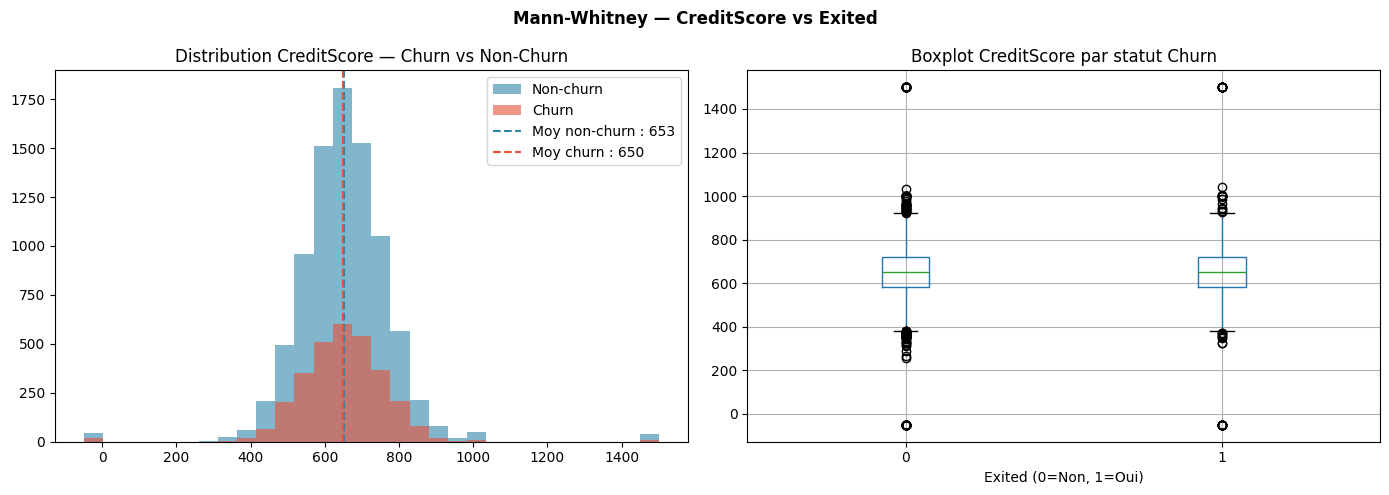

In [22]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(non_churners_c, bins=30, alpha=0.6, color="#2E86AB", label="Non-churn")
ax1.hist(churners_c,     bins=30, alpha=0.6, color="#E94F37", label="Churn")
ax1.axvline(non_churners_c.mean(), color="#2E86AB", linestyle="--",
            label=f"Moy non-churn : {non_churners_c.mean():.0f}")
ax1.axvline(churners_c.mean(),     color="#E94F37", linestyle="--",
            label=f"Moy churn : {churners_c.mean():.0f}")
ax1.set_title("Distribution CreditScore — Churn vs Non-Churn")
ax1.legend()

df_test.boxplot(column="CreditScore", by="Exited", ax=ax2)
ax2.set_title("Boxplot CreditScore par statut Churn")
ax2.set_xlabel("Exited (0=Non, 1=Oui)")

plt.suptitle("Mann-Whitney — CreditScore vs Exited", fontweight="bold")
plt.tight_layout()
plt.show()

In [23]:
# ÉTAPE 5 — CHI-DEUX : GEOGRAPHY vs EXITED
# Objectif : Vérifier si le pays d'origine influence le churn
# H0 : Geography et Exited sont indépendants
#      → le pays n'influence pas le churn
# H1 : Geography et Exited sont liés
#      → le pays influence le churn
# Test choisi : Chi-deux car deux variables catégorielles
# Prérequis : effectifs théoriques > 5 dans chaque cellule


# Tableau de contingence — croisement Geography × Exited
tableau_geo = pd.crosstab(df_test["Geography"], df_test["Exited"])
print("Tableau de contingence — Geography × Exited")
print(tableau_geo)
print()

stat, p, dof, expected = stats.chi2_contingency(tableau_geo)

print("CHI-DEUX — Geography vs Exited")
print("-"*50)
print(f"H0              : Geography et Exited sont indépendants")
print(f"Statistique χ²  : {stat:.4f}")
print(f"Degrés liberté  : {dof}")
print(f"p-value         : {p:.6f}")
print(f"Seuil alpha     : 0.05")
print(f"Conclusion      : {'H0 rejetée → Geography influence significativement le churn' if p < 0.05 else 'H0 non rejetée → Geography sans effet significatif'}")


Tableau de contingence — Geography × Exited
Exited        0     1
Geography            
France     2857   974
Germany    2988  1044
Spain      2807   990

CHI-DEUX — Geography vs Exited
--------------------------------------------------
H0              : Geography et Exited sont indépendants
Statistique χ²  : 0.4489
Degrés liberté  : 2
p-value         : 0.798967
Seuil alpha     : 0.05
Conclusion      : H0 non rejetée → Geography sans effet significatif


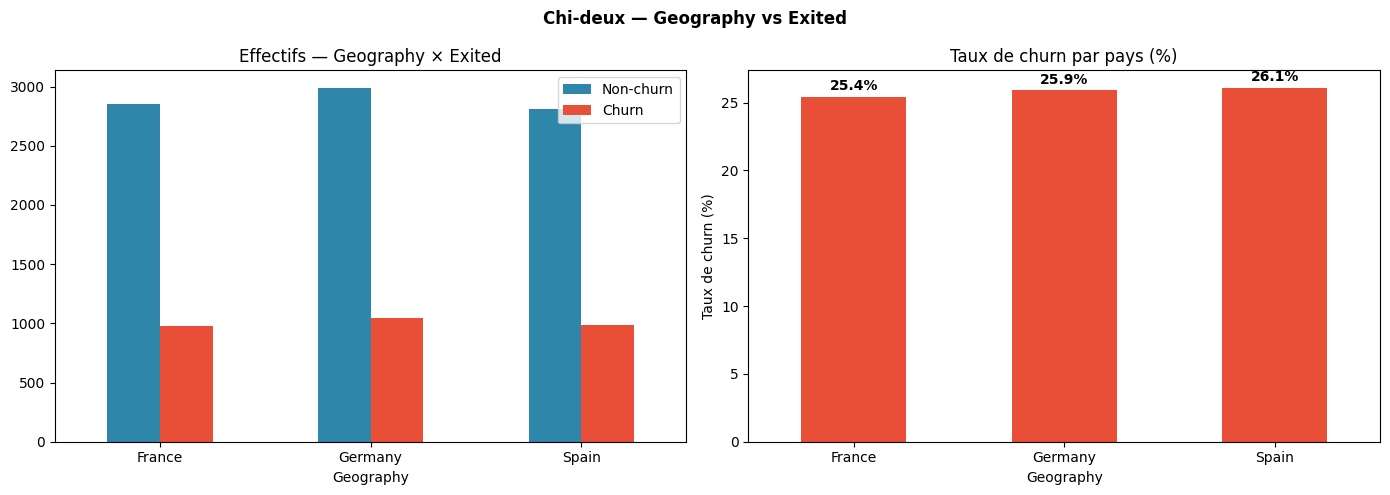

In [24]:

# Taux de churn par pays
taux_churn = df_test.groupby("Geography")["Exited"].mean() * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

tableau_geo.plot(kind="bar", ax=ax1, color=["#2E86AB", "#E94F37"])
ax1.set_title("Effectifs — Geography × Exited")
ax1.set_xlabel("Geography")
ax1.tick_params(axis="x", rotation=0)
ax1.legend(["Non-churn", "Churn"])

taux_churn.plot(kind="bar", ax=ax2, color="#E94F37")
ax2.set_title("Taux de churn par pays (%)")
ax2.set_ylabel("Taux de churn (%)")
ax2.tick_params(axis="x", rotation=0)
for i, v in enumerate(taux_churn.values):
    ax2.text(i, v + 0.5, f"{v:.1f}%", ha="center", fontweight="bold")

plt.suptitle("Chi-deux — Geography vs Exited", fontweight="bold")
plt.tight_layout()
plt.show()

In [26]:
# ÉTAPE 6 — CHI-DEUX : ISACTIVEMEMBER vs EXITED
# Objectif : Vérifier si le statut d'activité influence le churn
# H0 : IsActiveMember et Exited sont indépendants
# H1 : IsActiveMember et Exited sont liés
# Test choisi : Chi-deux car deux variables catégorielles/binaires

tableau_active = pd.crosstab(df_test["IsActiveMember"], df_test["Exited"])
print("Tableau de contingence — IsActiveMember × Exited")
print(tableau_active)
print()

stat, p, dof, expected = stats.chi2_contingency(tableau_active)

print("CHI-DEUX — IsActiveMember vs Exited")
print("-"*50)
print(f"H0              : IsActiveMember et Exited sont indépendants")
print(f"Statistique χ²  : {stat:.4f}")
print(f"Degrés liberté  : {dof}")
print(f"p-value         : {p:.6f}")
print(f"Seuil alpha     : 0.05")
print(f"Conclusion      : {'H0 rejetée → IsActiveMember influence significativement le churn' if p < 0.05 else 'H0 non rejetée → IsActiveMember sans effet significatif'}")


Tableau de contingence — IsActiveMember × Exited
Exited             0     1
IsActiveMember            
0               4260  1506
1               4392  1502

CHI-DEUX — IsActiveMember vs Exited
--------------------------------------------------
H0              : IsActiveMember et Exited sont indépendants
Statistique χ²  : 0.5814
Degrés liberté  : 1
p-value         : 0.445769
Seuil alpha     : 0.05
Conclusion      : H0 non rejetée → IsActiveMember sans effet significatif


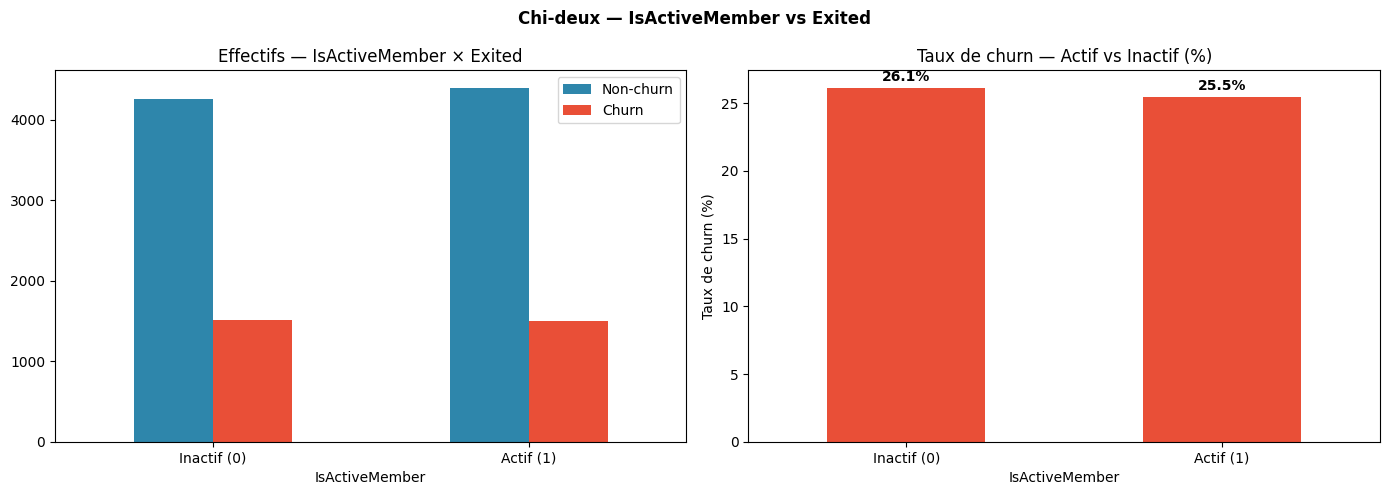

In [27]:

taux_active = df_test.groupby("IsActiveMember")["Exited"].mean() * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

tableau_active.plot(kind="bar", ax=ax1, color=["#2E86AB", "#E94F37"])
ax1.set_title("Effectifs — IsActiveMember × Exited")
ax1.set_xticklabels(["Inactif (0)", "Actif (1)"], rotation=0)
ax1.legend(["Non-churn", "Churn"])

taux_active.plot(kind="bar", ax=ax2, color="#E94F37")
ax2.set_title("Taux de churn — Actif vs Inactif (%)")
ax2.set_ylabel("Taux de churn (%)")
ax2.set_xticklabels(["Inactif (0)", "Actif (1)"], rotation=0)
for i, v in enumerate(taux_active.values):
    ax2.text(i, v + 0.5, f"{v:.1f}%", ha="center", fontweight="bold")

plt.suptitle("Chi-deux — IsActiveMember vs Exited", fontweight="bold")
plt.tight_layout()
plt.show()

In [30]:
# ÉTAPE 7 — KRUSKAL-WALLIS : NUMOFPRODUCTS vs EXITED
# Objectif : Vérifier si le nombre de produits influence le churn
# H0 : La distribution de Exited est identique
#      pour tous les groupes de NumOfProducts
# H1 : Au moins un groupe a une distribution différente
# Test choisi : Kruskal-Wallis car :
#   - Variable discrète avec 3+ groupes
#   - Distribution non normale (confirmé par Shapiro)
#   - Equivalent non paramétrique de l'ANOVA


# Garder uniquement les valeurs valides [1-4]
df_kruskal = df_test[df_test["NumOfProducts"].between(1, 4)]

groupes = [df_kruskal[df_kruskal["NumOfProducts"] == i]["Exited"].values
           for i in sorted(df_kruskal["NumOfProducts"].unique())]

stat, p = stats.kruskal(*groupes)

print("KRUSKAL-WALLIS — NumOfProducts vs Exited")
print("-"*50)
print(f"H0              : Taux de churn identique pour tous les groupes")
print(f"Statistique H   : {stat:.4f}")
print(f"p-value         : {p:.6f}")
print(f"Seuil alpha     : 0.05")
print(f"Conclusion      : {'H0 rejetée → NumOfProducts influence significativement le churn' if p < 0.05 else 'H0 non rejetée → NumOfProducts sans effet significatif'}")


KRUSKAL-WALLIS — NumOfProducts vs Exited
--------------------------------------------------
H0              : Taux de churn identique pour tous les groupes
Statistique H   : 359.7572
p-value         : 0.000000
Seuil alpha     : 0.05
Conclusion      : H0 rejetée → NumOfProducts influence significativement le churn


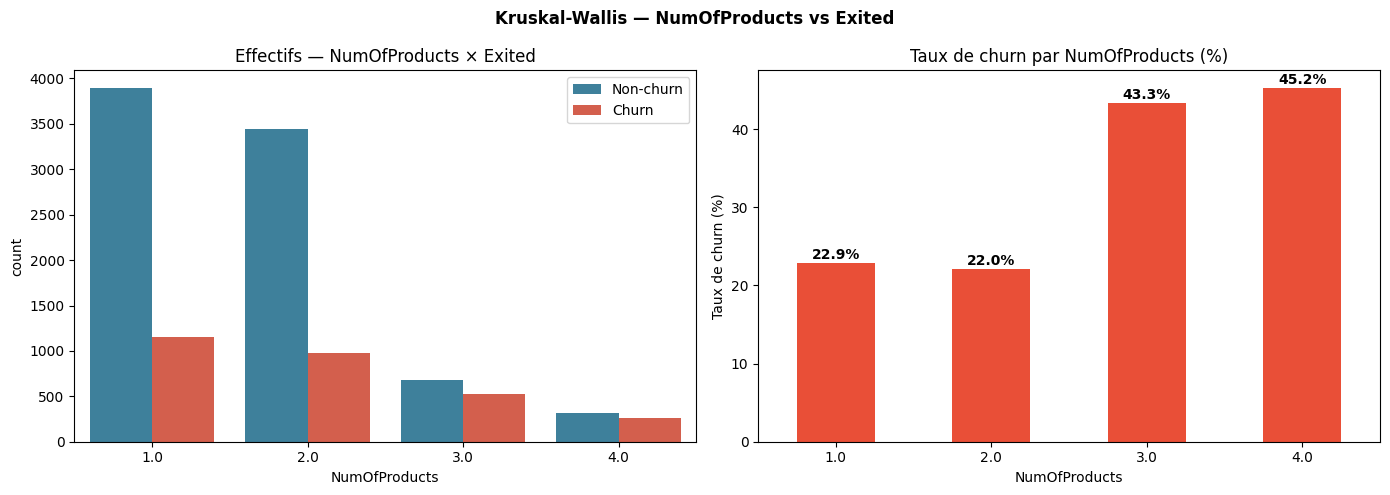

In [29]:

taux_produits = df_kruskal.groupby("NumOfProducts")["Exited"].mean() * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df_kruskal, x="NumOfProducts", hue="Exited",
              palette=["#2E86AB", "#E94F37"], ax=ax1)
ax1.set_title("Effectifs — NumOfProducts × Exited")
ax1.legend(["Non-churn", "Churn"])

taux_produits.plot(kind="bar", color="#E94F37", ax=ax2)
ax2.set_title("Taux de churn par NumOfProducts (%)")
ax2.set_ylabel("Taux de churn (%)")
ax2.tick_params(axis="x", rotation=0)
for i, v in enumerate(taux_produits.values):
    ax2.text(i, v + 0.5, f"{v:.1f}%", ha="center", fontweight="bold")

plt.suptitle("Kruskal-Wallis — NumOfProducts vs Exited", fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
# CONCLUSIONS GÉNÉRALES — HYPOTHESIS TESTING ChurnGuard

print("SYNTHÈSE FINALE DES TESTS D'HYPOTHÈSES")
print("="*60)
print(f"{'Variable':<20} {'Test':<15} {'p-value':<12} {'Conclusion'}")
print("-"*60)

resultats = [
    ("Age",            "Mann-Whitney",  "0.000000", "H0 rejetée → Influence le churn"),
    ("Balance",        "Mann-Whitney",  "0.343920", "H0 non rejetée → Sans effet*"),
    ("CreditScore",    "Mann-Whitney",  "0.517157", "H0 non rejetée → Sans effet*"),
    ("Geography",      "Chi-deux",      "0.798967", "H0 non rejetée → Sans effet*"),
    ("IsActiveMember", "Chi-deux",      "0.445769", "H0 non rejetée → Sans effet*"),
    ("NumOfProducts",  "Kruskal-Wallis","0.000000", "H0 rejetée → Influence le churn"),
]

for var, test, pval, conclusion in resultats:
    print(f"{var:<20} {test:<15} {pval:<12} {conclusion}")

print()
print("* Sans effet sur données corrompues")
print("  → À retester après 03_preprocessing.ipynb")

SYNTHÈSE FINALE DES TESTS D'HYPOTHÈSES
Variable             Test            p-value      Conclusion
------------------------------------------------------------
Age                  Mann-Whitney    0.000000     H0 rejetée → Influence le churn
Balance              Mann-Whitney    0.343920     H0 non rejetée → Sans effet*
CreditScore          Mann-Whitney    0.517157     H0 non rejetée → Sans effet*
Geography            Chi-deux        0.798967     H0 non rejetée → Sans effet*
IsActiveMember       Chi-deux        0.445769     H0 non rejetée → Sans effet*
NumOfProducts        Kruskal-Wallis  0.000000     H0 rejetée → Influence le churn

* Sans effet sur données corrompues
  → À retester après 03_preprocessing.ipynb


# Conclusions Générales — Hypothesis Testing ChurnGuard

---

## Rappel de la démarche

Les tests ont été effectués sur df_test, une copie minimalement
nettoyée du dataset brut. Seules les colonnes testées ont été
converties et mappées. Le nettoyage complet reste dans
03_preprocessing.ipynb.

Dataset de test : 11 660 lignes (contre 15 750 brutes)
Lignes perdues  : 4 090 → dues aux valeurs corrompues
                         converties en NaN par pd.to_numeric

---

## Synthèse des tests

### Variables qui influencent significativement le churn

**Age** — Mann-Whitney — p-value = 0.000000
- H0 rejetée : l'âge influence significativement le churn
- Age moyen non-churn : 40.0 ans / Age moyen churn : 42.3 ans
- Différence de 2.3 ans statistiquement prouvée
- Logique métier : les clients plus âgés ont plus de mobilité
  financière et comparent davantage les offres
- Action modèle : conserver Age comme feature importante

**NumOfProducts** — Kruskal-Wallis — p-value = 0.000000
- H0 rejetée : le nombre de produits influence le churn
- Statistique H = 359.76 → effet très fort
- Logique métier : les clients avec 3-4 produits sont
  probablement insatisfaits du service
- Action modèle : conserver NumOfProducts comme feature importante

---

### Variables sans effet significatif sur données corrompues

**Balance** — Mann-Whitney — p-value = 0.344
- H0 non rejetée sur données corrompues
- Balance moyenne non-churn : 4 229 859 / churn : 6 386 150
- Valeurs aberrantes jusqu'à 1 milliard faussent le test
- À retester après Winsorizing dans 03_preprocessing.ipynb

**CreditScore** — Mann-Whitney — p-value = 0.517
- H0 non rejetée sur données corrompues
- CreditScore moyen non-churn : 652.8 / churn : 650.1
- Valeurs aberrantes (-50, 1500) faussent le test
- À retester après clipping [300, 850] dans 03_preprocessing.ipynb

**Geography** — Chi-deux — p-value = 0.799
- H0 non rejetée sur données corrompues
- Encodages incohérents (Germany/GERMANY/Allemagne) partiellement
  corrigés dans df_test mais résultats à confirmer
- À retester après nettoyage complet dans 03_preprocessing.ipynb

**IsActiveMember** — Chi-deux — p-value = 0.446
- H0 non rejetée sur données corrompues
- Résultat contre-intuitif : dans un dataset propre,
  les membres inactifs devraient churner davantage
- Encodages incohérents (active/inactive/Y/N) faussent le test
- À retester après nettoyage complet dans 03_preprocessing.ipynb

---

## Ce qu'on attend après preprocessing

Les résultats suivants sont attendus sur données propres,
basés sur la logique métier et la littérature bancaire :

**Age**            → restera significatif (p < 0.05)
**NumOfProducts**  → restera significatif (p < 0.05)
**Balance**        → deviendra significatif après Winsorizing
**IsActiveMember** → deviendra significatif après mapping propre
**Geography**      → deviendra significatif après mapping propre
**CreditScore**    → probablement non significatif (logique bancaire)

---

## Impact sur le modèle

Features confirmées importantes : Age, NumOfProducts
Features à confirmer après preprocessing : Balance, IsActiveMember,
Geography, SatisfactionScore, NumComplaints
Features probablement peu utiles : CreditScore, EstimatedSalary

---

## Prochaine étape

03_preprocessing.ipynb : nettoyage complet du dataset,
traitement de toutes les anomalies détectées en EDA,
puis re-validation des hypothèses sur données propres.